**Name:-** Sarvesh Kulkarni <br/>

In [1]:
#import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**Load Dataset**

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3763s 22us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


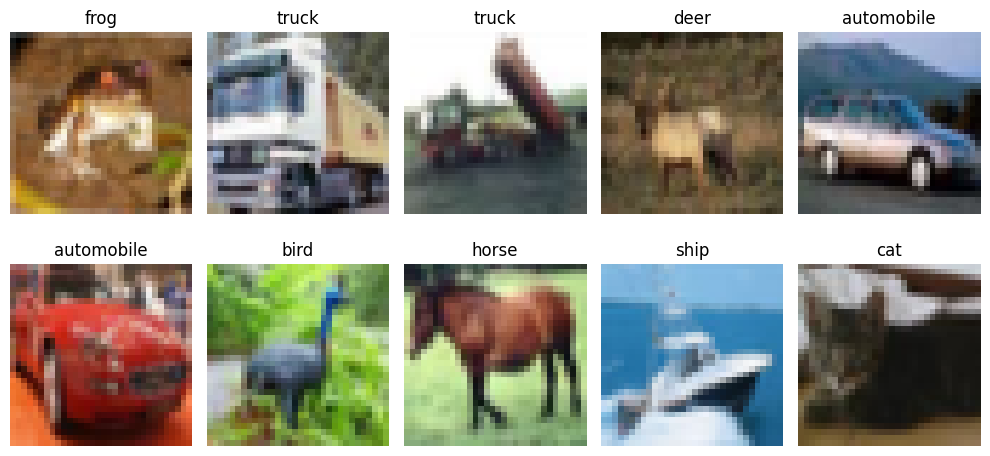

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

**Preprocessing**

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

## Part1:-ANN  model

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2648 - loss: 2.0053 - val_accuracy: 0.3378 - val_loss: 1.8474
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3099 - loss: 1.8761 - val_accuracy: 0.3698 - val_loss: 1.7596
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3330 - loss: 1.8252 - val_accuracy: 0.3706 - val_loss: 1.7530
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3471 - loss: 1.7854 - val_accuracy: 0.3520 - val_loss: 1.7887
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3655 - loss: 1.7513 - val_accuracy: 0.3830 - val_loss: 1.7134
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3675 - loss: 1.7386 - val_accuracy: 0.3924 - val_loss: 1.7181
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3709 - loss: 1.7237 - val_accuracy: 0.4072 - val_loss: 1.6602
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3762 - loss: 1.7081 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4098 - loss: 1.6428
ANN Test Accuracy: 0.4097999930381775


## Part2:-CNN model

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 128ms/step - accuracy: 0.4822 - loss: 1.4560 - val_accuracy: 0.5192 - val_loss: 1.3316
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.6222 - loss: 1.0891 - val_accuracy: 0.5660 - val_loss: 1.2336
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 126ms/step - accuracy: 0.6806 - loss: 0.9222 - val_accuracy: 0.5780 - val_loss: 1.3017
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 130ms/step - accuracy: 0.7210 - loss: 0.8026 - val_accuracy: 0.6712 - val_loss: 0.9285
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 133ms/step - accuracy: 0.7546 - loss: 0.7090 - val_accuracy: 0.6922 - val_loss: 0.9199
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 131ms/step - accuracy: 0.7785 - loss: 0.6302 - val_accuracy: 0.6614 - val_loss: 1.1444
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.8004 - loss: 0.5682 - val_accuracy: 0.7210 - val_loss: 0.8462
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.8214 - los

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7213 - loss: 0.8879
CNN Test Accuracy: 0.7213000059127808


**Comparing Learning objectives**

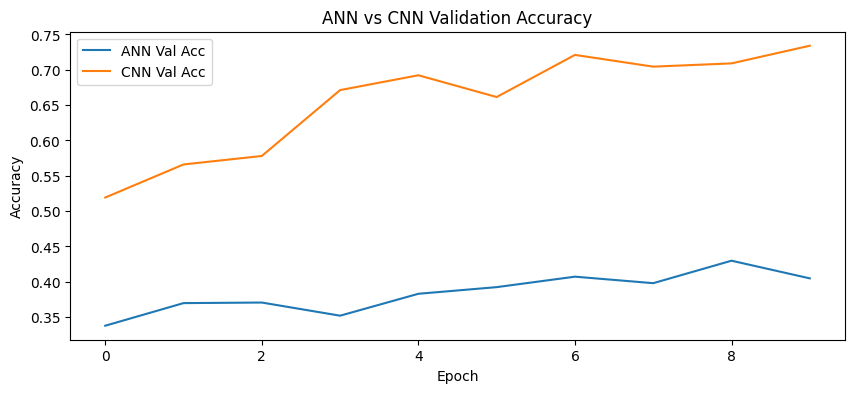

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
  81/1407 ━━━━━━━━━━━━━━━━━━━━ 1:04 49ms/step - accuracy: 0.1353 - loss: 2.2831

In [ ]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm,y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Augmented CNN Test Loss:", aug_test_loss)

**Comparison Table**

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]})
comparison


## Increased ANN  layers

In [ ]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')])
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)




In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

## Increase epochs

In [ ]:
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

In [ ]:
cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

In [ ]:
aug_history = aug_cnn_model.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,batch_size=64)

## Added early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

In [ ]:
history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[early_stop]
)

## Data Augmentation training

In [ ]:
aug_history = aug_cnn_model.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,batch_size=64,callbacks=[early_stop])

In [ ]:
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm,y_test)
print("Augmented CNN Accuracy:", aug_acc)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
"ANN",
        "CNN",
        "CNN + Data Augmentation"],
    "Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_acc]
})

comparison

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(aug_history.history['val_accuracy'],label='CNN + Aug')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.show()